In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from Files import Model
from Files import Tools
from Files import NEGM
from Files import HelperFunctions
from Files import Estimation

In [2]:
model = Model.DurableBufferStock()
model.modelSetup()
model.createGrids()
model.solve()
model.simulate()

par = model.par
sol = model.sol
sim = model.sim

Number of gridpoints: t = 50 p = 20 n = 50 m = 50
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
Step 1 total time: 1687.08 seconds
Step 2 total time: 25.05 seconds
Step 3 total time: 243.55 seconds
Step 4 total time: 3.55 seconds
Solver time: 1959.55 seconds
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
Simulation time: 255.73 seconds


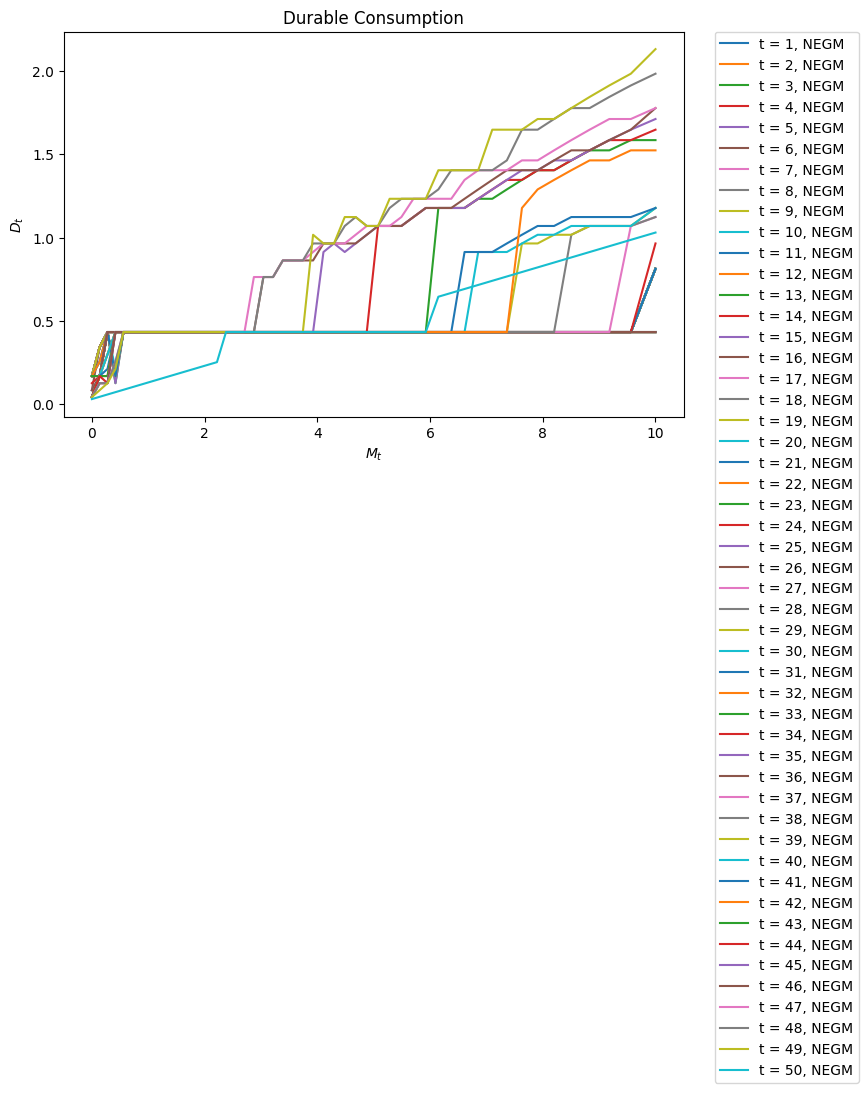

In [3]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):

    ax.plot(sol.m[t, 5, 10, :],sol.d[t, 5, 10, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$D_t$")
ax.set_title(f'Durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

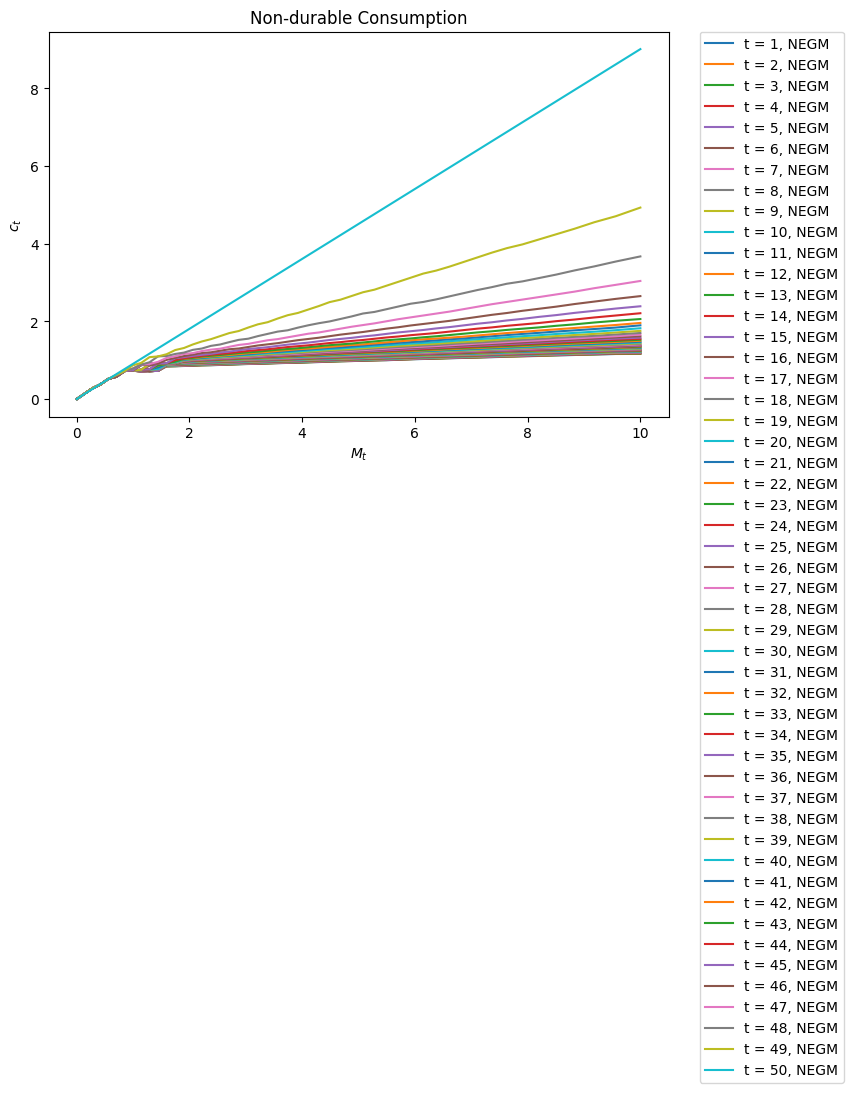

In [4]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.c[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Non-durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

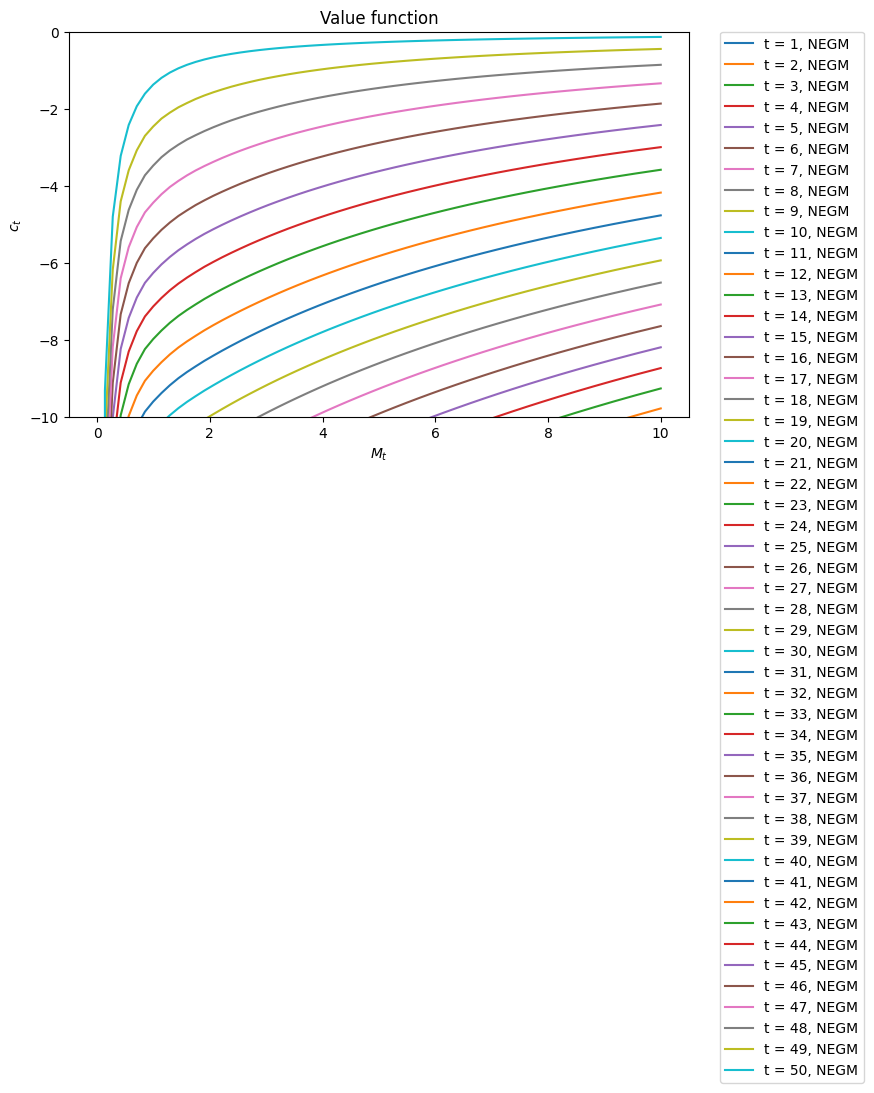

In [5]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.v[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Value function')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_ylim(bottom=-10,top=0)
plt.show()

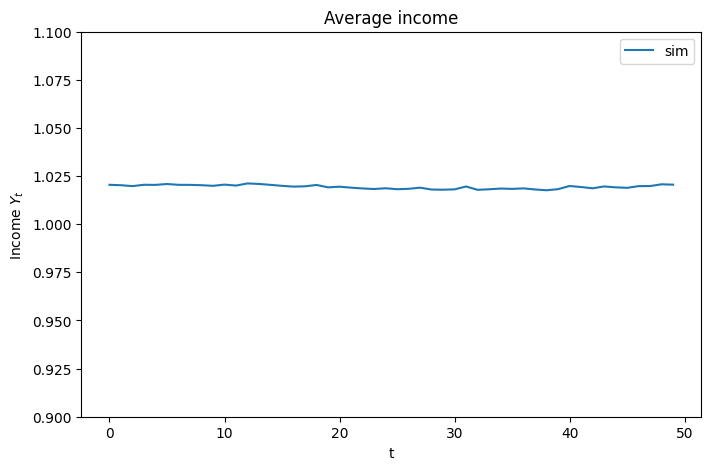

In [6]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.y, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Income $Y_t$")
ax.set_title(f'Average income')
ax.legend()
ax.set_ylim(bottom=0.9,top=1.1)
plt.show()

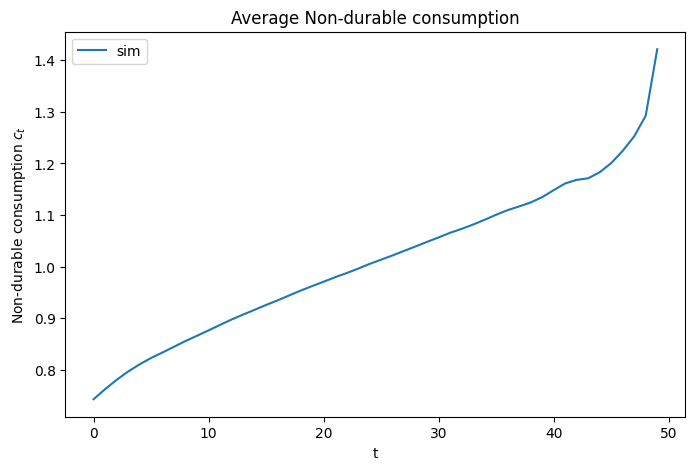

0.7429269707698547
0.7623514008751284


In [7]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.c, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Non-durable consumption $c_t$")
ax.set_title(f'Average Non-durable consumption')
ax.legend()
#ax.set_ylim(bottom=0.5,top=1.5)
plt.show()

print(np.mean(sim.c[0]))
print(np.mean(sim.c[1]))

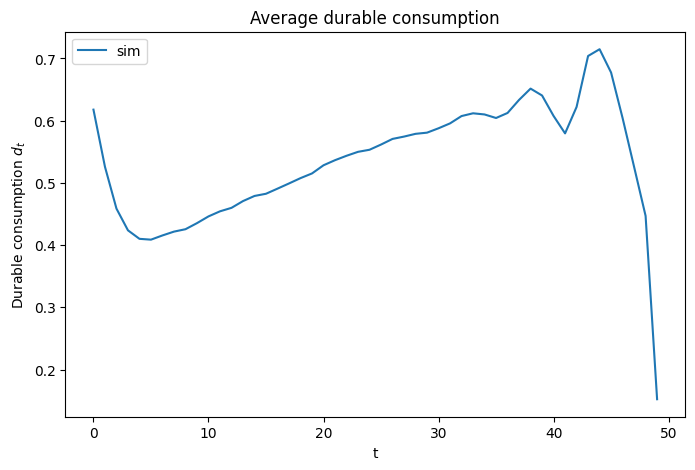

In [8]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.d, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Durable consumption $d_t$")
ax.set_title(f'Average durable consumption')
ax.legend()
plt.show()

In [9]:
np.mean(sim.c)

1.0117387965330285

In [10]:
np.mean(sim.c)-0.979

0.03273879653302847

In [11]:
np.var(sim.c)

0.30516046303950695

In [12]:
np.var(sim.c) - 0.256

0.04916046303950694

In [13]:
np.mean(sim.d)

0.5343639917979677

In [14]:
np.mean(sim.d) - 0.562

-0.02763600820203238

In [15]:
np.var(sim.d)

0.14864213852687636

In [16]:
np.var(sim.d) - 0.112

0.03664213852687635

In [17]:
np.mean(sim.v)

-21.678475280140027

In [18]:
np.mean(sim.v) + 32.213

10.534524719859974

In [19]:
np.mean(sim.v[0])

-36.0262753962291

In [20]:
sim.adjuster_share

AttributeError: 'types.SimpleNamespace' object has no attribute 'adjuster_share'

In [ ]:
np.mean(np.abs(sim.d - sim.n) > 1e-4)

0.678083

In [ ]:
np.mean(np.abs(sim.d - sim.n) > 1e-1)

0.2173606

In [ ]:
diff = np.abs(sim.d - sim.n)

print(np.percentile(diff, [0, 25, 50, 75, 90, 95, 99]))

[0.00000000e+00 1.11022302e-16 1.99242479e-02 8.02215835e-02
 2.47710408e-01 4.33939405e-01 8.33758200e-01]


In [ ]:
tol = 0.05
np.mean(np.abs(sim.d - sim.n) > tol)

0.3314096